#### Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import pickle
import warnings
import os
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings('ignore')

from kmrf import KMRF
from KMRF_training_config import *
from MODEL_INFO import MODEL_INFO
from ANALYTICAL_INPUTS import ANALYTICAL_INPUTS
from PORTFOLIO_OPTIMIZER import PORTFOLIO_OPTIMIZER
from BACKTEST_ANALYTICAL import BACKTEST

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import itables
itables.init_notebook_mode()
import pygwalker as pyg

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


#### Global Vars and Helper Functions

In [28]:
KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')
KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')

# Using saved KAMA+MSR models
def get_KM_model_dates(KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) -> pd.Series:
    return pd.Series([f.stem for f in list(KM_MODEL_BASE_PATH.glob('*'))]).sort_values().iloc[1:].reset_index(drop=True)

def get_KM_model_paths(MODEL_DATE: str, KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) ->  pd.Series:
    return pd.Series(list((KM_MODEL_BASE_PATH / MODEL_DATE).glob('*'))).sort_values().reset_index(drop=True)

# Using saved KMRF predictions
def get_asset_names(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    kmrf_preds_paths = list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))
    return pd.Series([f.stem.split('multi')[0][:-1].replace('_', ' ') for f in kmrf_preds_paths]).sort_values().reset_index(drop=True)

def get_KMRF_prediction_paths(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    return pd.Series(list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))).sort_values().reset_index(drop=True)

In [29]:
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

TRADING_DAYS = CustomBusinessDay(calendar=USFederalHolidayCalendar())

RF_RATES_TS = pd.read_csv('data/risk_free_rates.csv', parse_dates=['Date'], index_col='Date')[['RF_3M']].sort_index()

# ----------------------------------------------------

In [30]:
KM_MODEL_DATES = get_KM_model_dates()

In [31]:
START_DATE = KM_MODEL_DATES.iloc[0]
END_DATE = '20251031'

N_FREQ = 10 # Edit this
ALLOW_SHORT = False # Edit this

GROSS_EXPOSURE_LIMIT = 2.0 if ALLOW_SHORT else 1.0
MIN_WEIGHT = -0.5 if ALLOW_SHORT else 0.0
MAX_WEIGHT = 1.0

OBJECTIVE = 'max_sharpe'  # max_sharpe, min_variance, risk_parity, or mean_variance
RISK_AVERSION = 1.0  # Only used if OBJECTIVE is 'mean_variance'

In [32]:
assets_type = 'general' # Edit this

if OBJECTIVE == 'mean_variance':
    subfolder = 'mean_variance_no_constraints'  # Edit this
elif OBJECTIVE == 'min_variance':
    subfolder = 'min_variance_no_constraints'  # Edit this
elif OBJECTIVE == 'risk_parity':
    subfolder = 'risk_parity_no_constraints'  # Edit this
else:
    subfolder = 'max_sharpe_no_constraints'  # Edit this

investment_type = 'long-short' if ALLOW_SHORT else 'long-only'
investment_type_w_gross = f'long-short_gross={GROSS_EXPOSURE_LIMIT}' if ALLOW_SHORT else f'long-only'

filename = f'{assets_type}_{investment_type_w_gross}_'
if OBJECTIVE == 'mean_variance':
    filename += f'risk-aversion={RISK_AVERSION}_'
filename += f'{N_FREQ}d-rebal_{START_DATE}-{END_DATE}.pkl'

filename

'general_long-only_10d-rebal_20181231-20251031.pkl'

In [33]:
with open(os.path.join('saved_backtests', subfolder, f'{assets_type}_universe', investment_type, filename), 'rb') as f:
    bt = pickle.load(f)

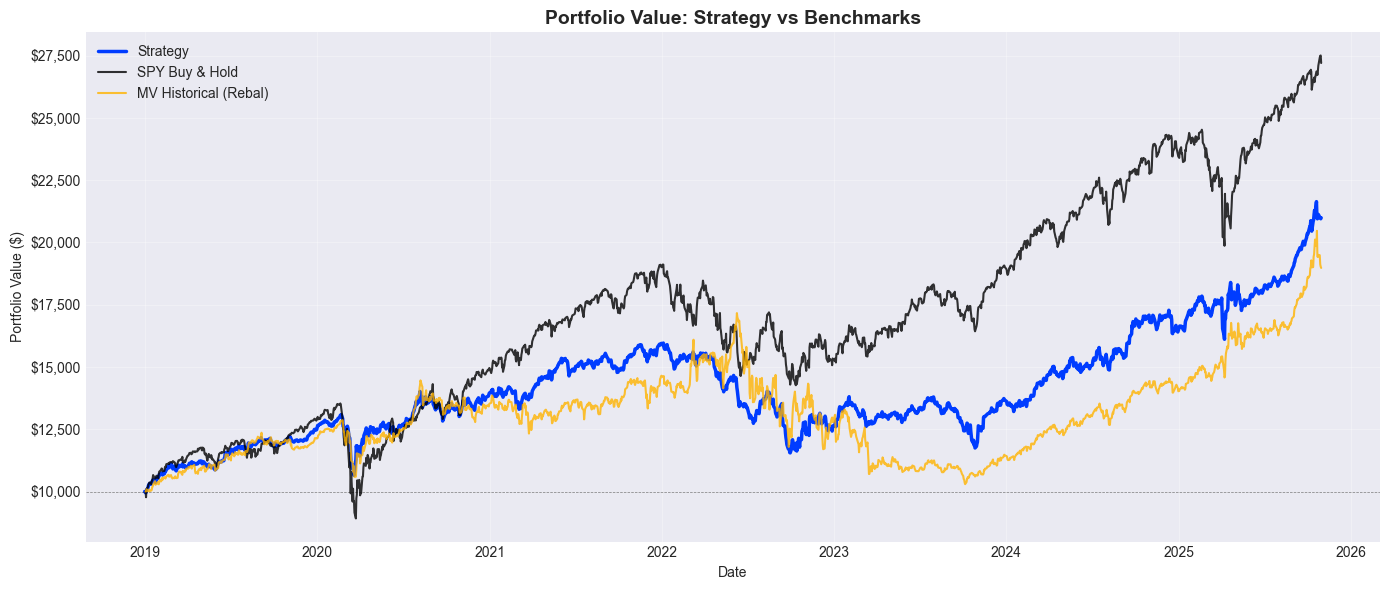

In [34]:
bt.plot_performance()

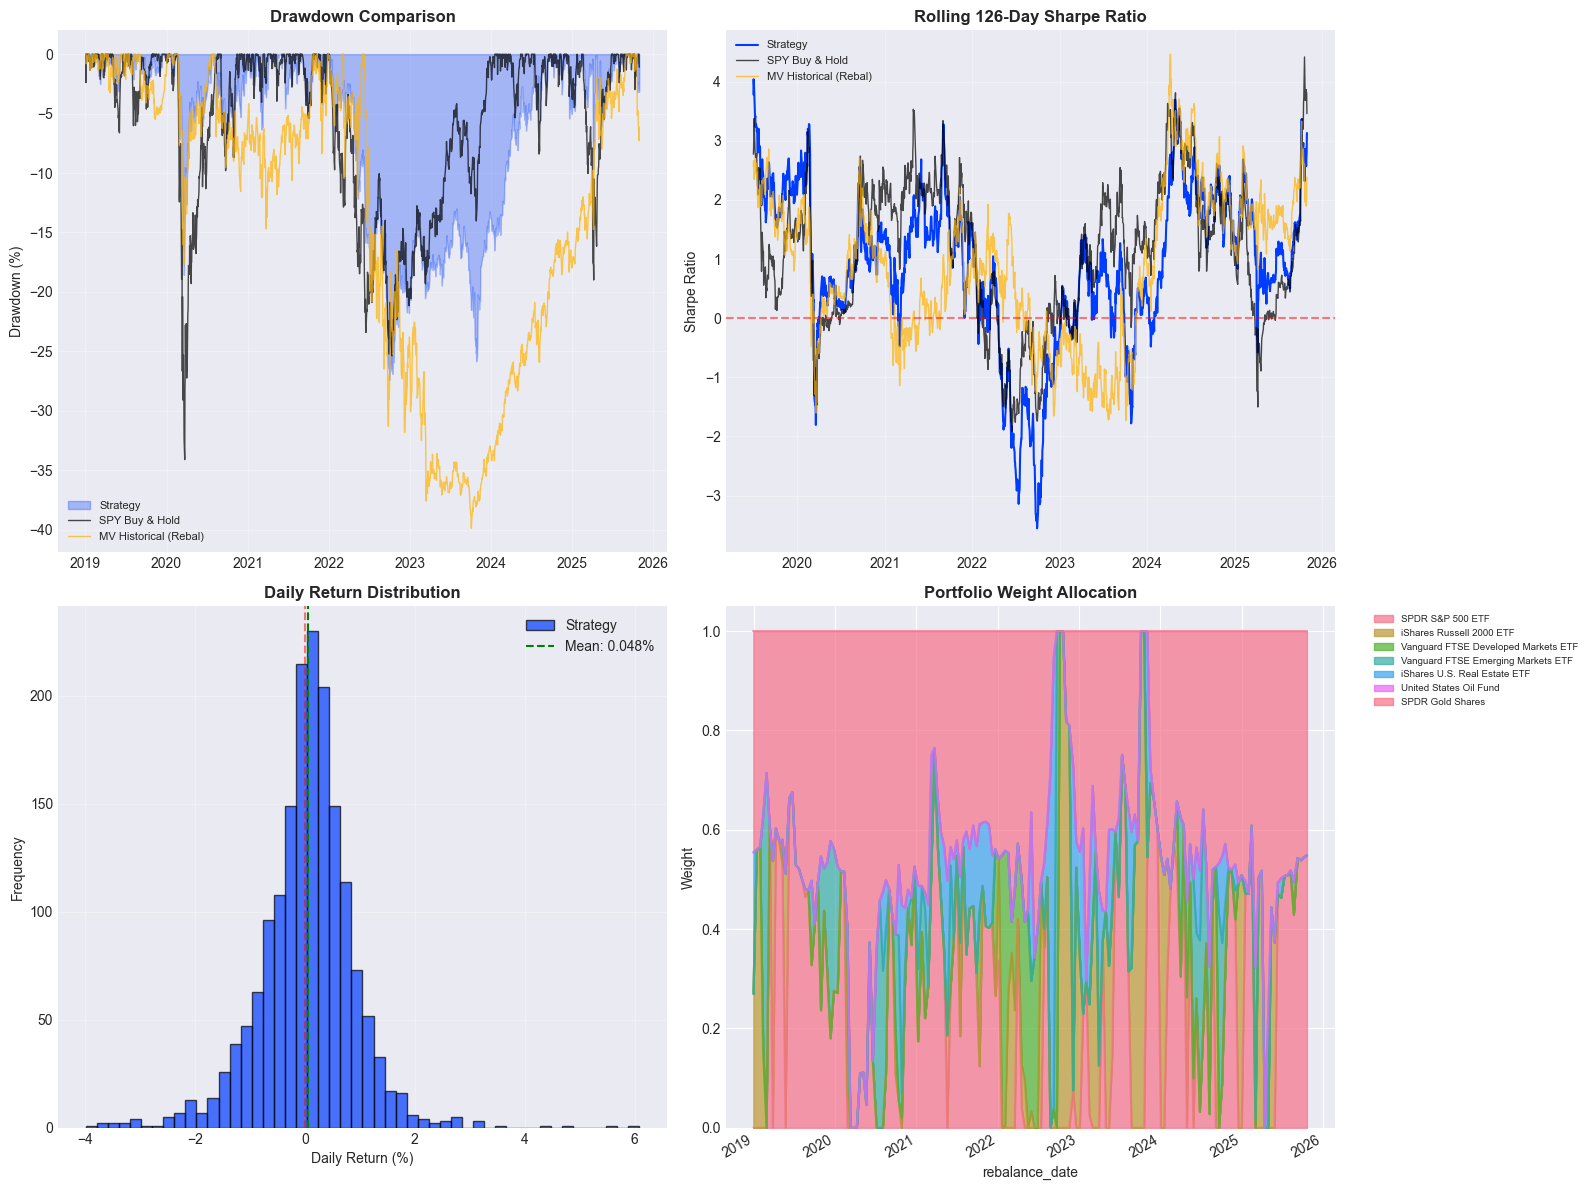

In [35]:
bt.plot_detailed_analysis()

In [36]:
bt.print_summary()


BACKTEST PERFORMANCE SUMMARY
Period: 2018-12-31 to 2025-10-31
Trading Days: 1718
Rebalances: 172

Metric                           Strategy         SPY B&H   MV Hist Rebal
-------------------------------------------------------------------------------------
Total Return                      109.88%         171.74%          89.76%
Annualized Return                  11.49%          15.79%           9.85%
Annualized Volatility              13.78%          19.99%          19.22%
Sharpe Ratio                        0.636           0.654           0.371
Sortino Ratio                       0.867           0.797           0.440
Max Drawdown                      -27.40%         -34.10%         -39.88%
Win Rate                           56.52%          55.59%          56.98%

Total Transaction Costs: $314.97
Average Turnover per Rebalance: 26.50%


In [37]:
bt.get_exposure_summary()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [38]:
bt.weights_history.map("{:.2%}".format)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [39]:
bt.get_benchmark_weights('MV Historical (Rebal)').map("{:.2%}".format)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
